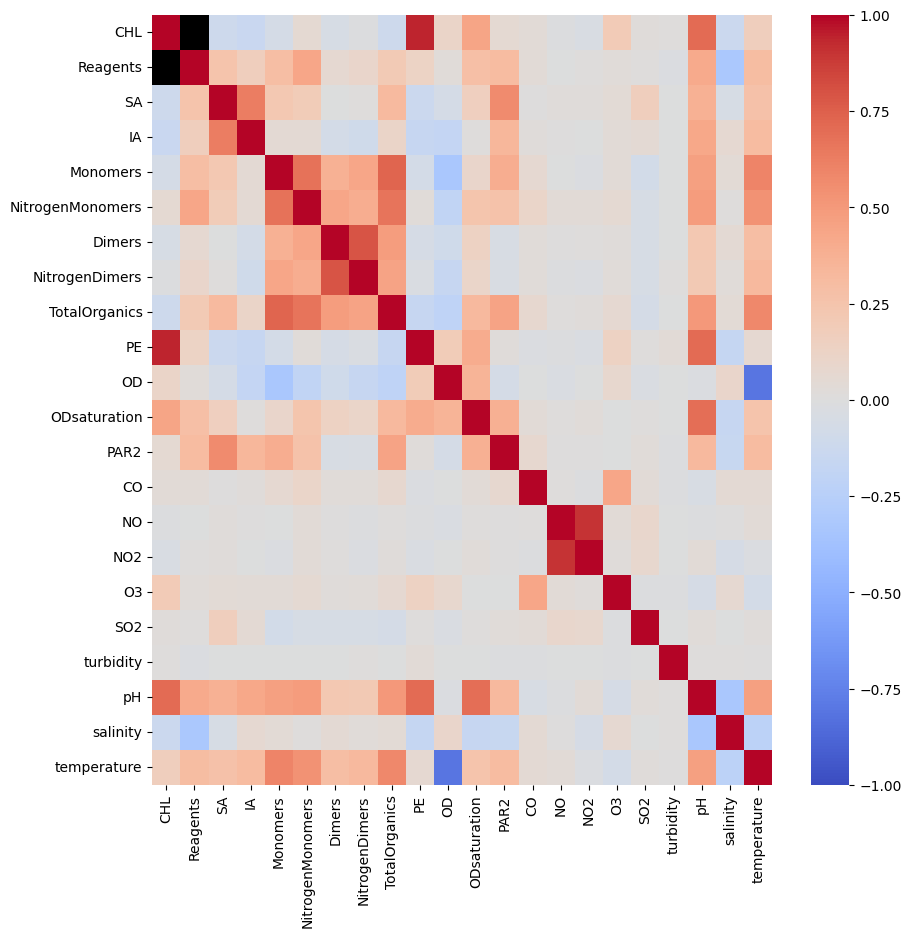

In [63]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


DATA_BASE_PATH = "../local/Tvarminne/preprocessed_all"

path = Path(f"{DATA_BASE_PATH}/")
files_to_process = path.glob("*.csv")
dfs = []
for file in files_to_process:
    df = pd.read_csv(file, engine='pyarrow', index_col="Time")
    df.sort_index()
    dfs.append(df)

df = pd.concat(dfs, axis=1, sort=True)
df.columns = df.columns.str.split('_').str[0]

corr = df.corr()
high_corr = (corr.where(np.eye(corr.shape[0],dtype=bool))
                    .stack()
                    .sort_values(ascending=False))

pairs_to_mask = [
    ("CHL", "Reagents"),
]

mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
for f1, f2 in pairs_to_mask:
    mask.loc[f1, f2] = True
    mask.loc[f2, f1] = True

plt.figure(figsize=(10,10))

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="black") 

sns.heatmap(
    df.corr(), 
    xticklabels=1, 
    yticklabels=1,
    vmin=-1, 
    vmax=1, 
    center=0, 
    mask=mask,
    cmap=cmap
    # annot=True,
    )

plt.show()

# hierarchical agglomerative clustering based on correlation distance

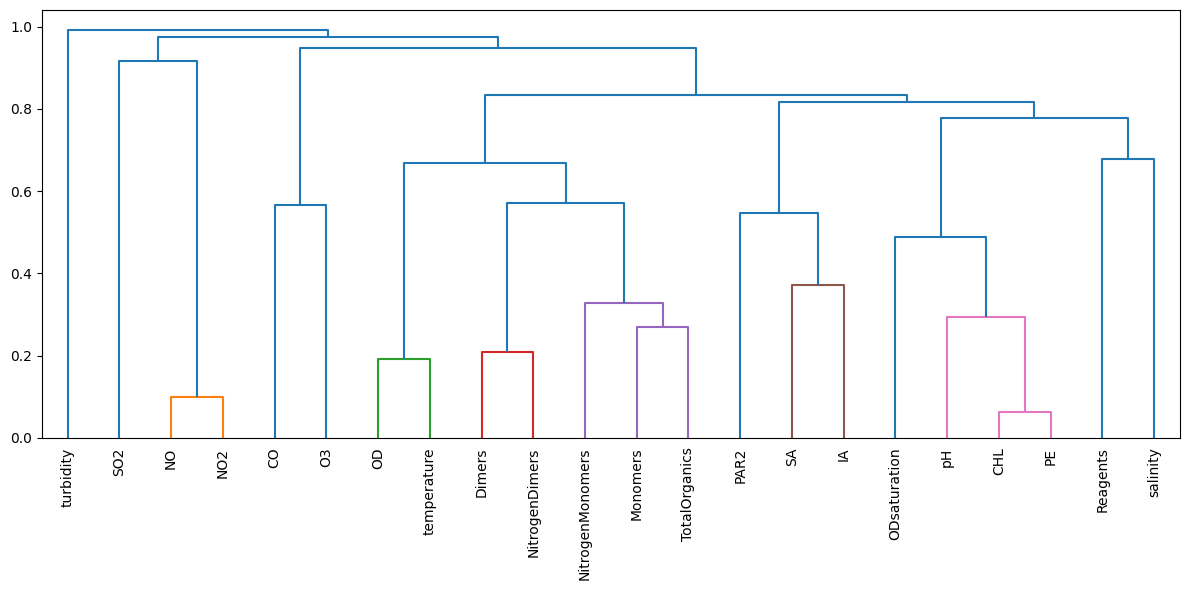

In [64]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial.distance import pdist, squareform

def cluster(df_x):
    corr = df_x.corr().abs()
    distance = 1 - corr
    condensed_distance = squareform(distance.values)

    Z = linkage(condensed_distance, method='average')
    cluster_labels = fcluster(Z, t=0.3, criterion='distance')
    groups = pd.DataFrame({'feature': corr.columns, 'cluster': cluster_labels})
    groups = groups.sort_values('cluster')
    clusters = groups.groupby('cluster')['feature'].apply(list)

    return clusters, corr, Z

clusters_den, corr_den, Z_den = cluster(df)


plt.figure(figsize=(12, 6))
dendrogram(Z_den, labels=df.columns, leaf_rotation=90, color_threshold=0.4)
plt.tight_layout()
plt.show()